In [1]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import numpy as np
from sklearn.mixture import GaussianMixture
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
df_reddit = pd.read_csv('reddit_severity.csv')
df_reddit.head()

,Unnamed: 0,post_id,keyword,post_title,post_text,post_date,comments,source_method,post_text_clean,comments_clean,...,vader_neu,vader_pos,vader_compound,vader_sentiment,tb_polarity,tb_subjectivity,tb_sentiment,otsu_class,jenks_class,gmm_class
0,0,1dg7p5a,depression,I wish someone would just...,Just fucking kill me. Shoot me. I wish I could...,2024-06-15 11:54:16,['Life is overall shitty and borderline unbear...,top,fucking kill shoot wish bed fucking wake anymo...,life overall shitty borderline unbearable goin...,...,0.609,0.164,-0.9783,negative,-0.119479,0.581493,negative,negative,negative,negative
1,1,1dga2ht,depression,A friend of mine once described depression as ...,And felt like that is the most apt description...,2024-06-15 14:12:57,['Whenever I was younger and when I was at my ...,top,felt apt description heard feels agree,younger lowest said home got older continued r...,...,0.607,0.265,0.7783,positive,-0.053571,0.839286,negative,positive,positive,positive
2,2,1f96hl3,depression,Therapist explained to me that normally people...,This has destroyed me. I’ve always thought may...,2024-09-05 07:54:46,['Sometimes I stew for HOURS on this. How are ...,top,destroyed thought maybe severely depressed tol...,stew hours constantly gutted life surprises re...,...,0.683,0.192,0.8602,positive,0.018044,0.610440,neutral,positive,positive,positive
3,3,1g9mnuy,depression,"Everyone says if you're depressed, don't be af...","Well, we try to. And guess what? No one cares....",2024-10-23 03:11:27,"[""Thing is, even if someone did care, I do not...",top,try guess cares busy lives problems hear youre...,did care dump issues burden literally wont car...,...,0.618,0.102,-0.9637,negative,0.020000,0.740000,neutral,negative,negative,negative
4,4,1g5uwhx,depression,Quiet quitting life,I am quiet quitting life and nobody realizes t...,2024-10-18 02:56:16,['Man holy shit I’ve never related to somethin...,top,quiet quitting life realizes friends think bad...,man holy shit related life right doing years s...,...,0.801,0.157,0.9609,positive,0.133550,0.592857,positive,positive,positive,positive


In [3]:


import json, numpy as np, pandas as pd, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "SamLowe/roberta-base-go_emotions"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
id2label  = model.config.id2label
labels_order = [id2label[i] for i in range(len(id2label))]

@torch.no_grad()
def goemotion_scores(texts, batch_size=16, max_length=256):
    probs = []
    model.eval()
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size],
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        p = torch.sigmoid(model(**enc).logits).detach().cpu().numpy()
        probs.append(p)
    return np.vstack(probs)

def apply_goemotions(df, text_col="text_clean", threshold=0.30, prefix="goe_"):
    texts = df[text_col].fillna("").astype(str).tolist()
    P = goemotion_scores(texts)

    # per-emotion columns
    for j, lab in enumerate(labels_order):
        df[f"{prefix}{lab}_prob"] = P[:, j].astype("float32")
        df[f"{prefix}{lab}"]      = (P[:, j] >= threshold).astype("int8")

    # ---- FIXED TOP-3 (use row[j], not 'p') ----
    top3_list = []
    for row in P:                      # row is a 1D numpy array of probs
        idx = np.argsort(-row)[:3]     # top-3 indices
        top3 = [(labels_order[j], float(row[j])) for j in idx]
        top3_list.append(json.dumps(top3))
    df[f"{prefix}top3"] = top3_list

    # dominant, any_positive, sum_active
    df[f"{prefix}dominant"]    = [labels_order[i] for i in P.argmax(axis=1)]
    df[f"{prefix}any_positive"] = (P.max(axis=1) >= threshold).astype("int8")
    df[f"{prefix}sum_active"]   = (P >= threshold).sum(axis=1).astype("int16")
    return df
df_reddit = apply_goemotions(df_reddit, text_col="post_content", threshold=0.30, prefix="goe_")

/opt/anaconda3/envs/tf-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


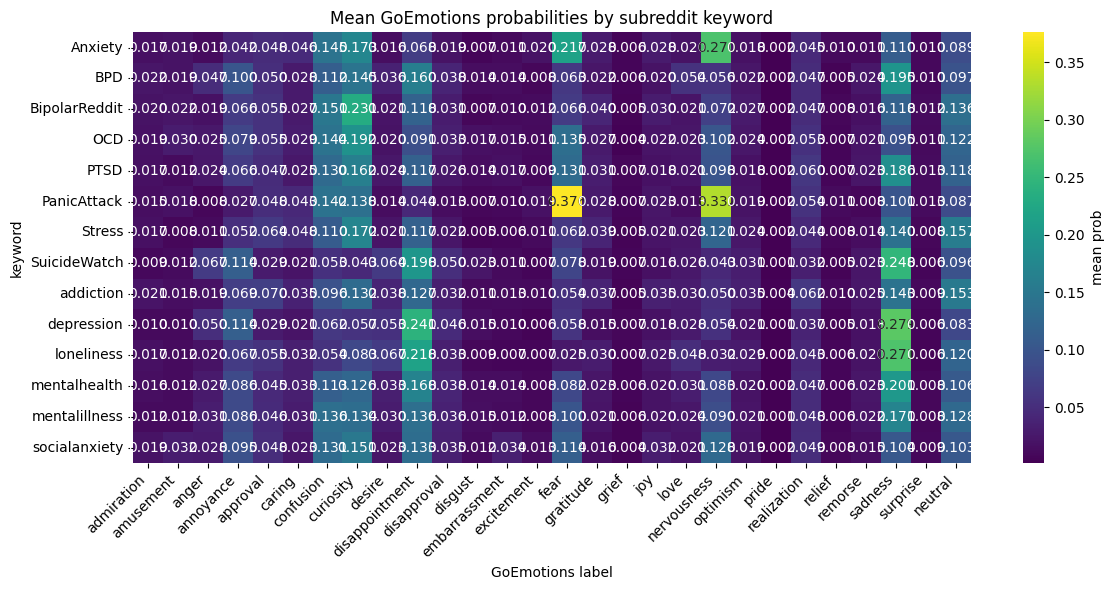

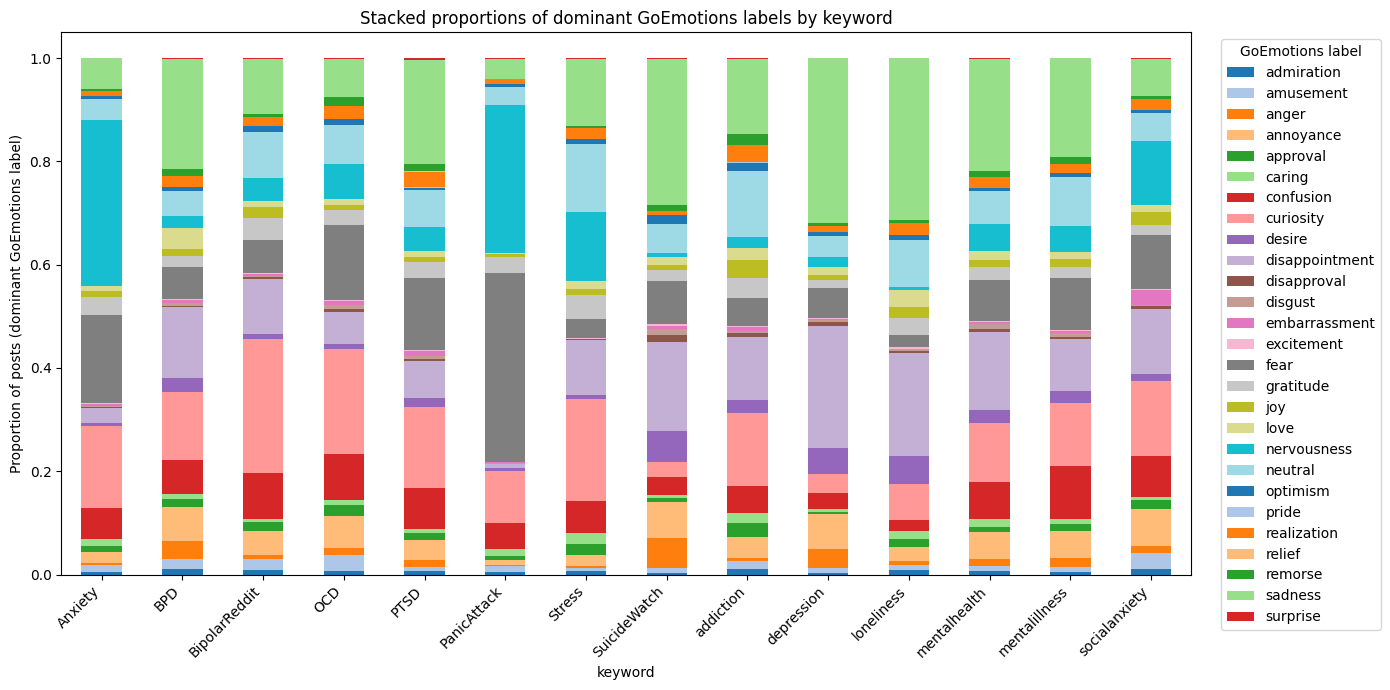

In [4]:
# Visualizations using GoEmotions (per-emotion probs + goe_dominant)
# Reuses df_reddit; will derive prob_cols / labels if not present

# ensure prob_cols (28 GoEmotions prob columns)
try:
    prob_cols
except NameError:
    prob_cols = [c for c in df_reddit.columns if c.startswith("goe_") and c.endswith("_prob")]

# derive friendly labels (remove prefix/suffix) if labels_order not available
try:
    goe_labels = labels_order
except NameError:
    goe_labels = [c[len("goe_"):-len("_prob")] for c in prob_cols]

# 1) Heatmap of mean GoEmotions probabilities per keyword
mean_goe = df_reddit.groupby("keyword")[prob_cols].mean()
mean_goe.columns = goe_labels  # nicer column names

# respect existing keyword ordering if available
try:
    kws = keywords
except NameError:
    kws = mean_goe.index.tolist()

plt.figure(figsize=(12, 6))
sns.heatmap(mean_goe.reindex(kws), cmap="viridis", annot=True, fmt=".3f",
            cbar_kws={"label": "mean prob"})
plt.title("Mean GoEmotions probabilities by subreddit keyword")
plt.ylabel("keyword")
plt.xlabel("GoEmotions label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2) Stacked bar chart of dominant GoEmotions proportions per keyword
dom_col = "goe_dominant"
if dom_col not in df_reddit.columns:
    raise RuntimeError(f"Column '{dom_col}' not found in df_reddit. Run apply_goemotions first.")

try:
    counts_goe = dominant_counts_goe.copy()
except NameError:
    counts_goe = df_reddit.groupby(["keyword", dom_col]).size().unstack(fill_value=0)

# ensure same keyword ordering
kws = kws if isinstance(kws, list) else counts_goe.index.tolist()
prop_goe = counts_goe.div(counts_goe.sum(axis=1), axis=0).reindex(kws).fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
n_labels = prop_goe.shape[1]
# choose palette that can handle many labels
palette = sns.color_palette("tab20", n_colors=max(10, n_labels))
prop_goe.plot(kind="bar", stacked=True, ax=ax, color=palette[:n_labels])
ax.set_ylabel("Proportion of posts (dominant GoEmotions label)")
ax.set_xlabel("keyword")
ax.set_title("Stacked proportions of dominant GoEmotions labels by keyword")
ax.legend(title="GoEmotions label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
df_reddit

,Unnamed: 0,post_id,keyword,post_title,post_text,post_date,comments,source_method,post_text_clean,comments_clean,...,goe_sadness_prob,goe_sadness,goe_surprise_prob,goe_surprise,goe_neutral_prob,goe_neutral,goe_top3,goe_dominant,goe_any_positive,goe_sum_active
0,0,1dg7p5a,depression,I wish someone would just...,Just fucking kill me. Shoot me. I wish I could...,2024-06-15 11:54:16,['Life is overall shitty and borderline unbear...,top,fucking kill shoot wish bed fucking wake anymo...,life overall shitty borderline unbearable goin...,...,0.140615,0,0.001754,0,0.032973,0,"[[""annoyance"", 0.4284030497074127], [""disappoi...",annoyance,1,1
1,1,1dga2ht,depression,A friend of mine once described depression as ...,And felt like that is the most apt description...,2024-06-15 14:12:57,['Whenever I was younger and when I was at my ...,top,felt apt description heard feels agree,younger lowest said home got older continued r...,...,0.168948,0,0.002471,0,0.067588,0,"[[""approval"", 0.25582194328308105], [""curiosit...",approval,0,0
2,2,1f96hl3,depression,Therapist explained to me that normally people...,This has destroyed me. I’ve always thought may...,2024-09-05 07:54:46,['Sometimes I stew for HOURS on this. How are ...,top,destroyed thought maybe severely depressed tol...,stew hours constantly gutted life surprises re...,...,0.126529,0,0.038628,0,0.059673,0,"[[""disappointment"", 0.42051759362220764], [""an...",disappointment,1,2
3,3,1g9mnuy,depression,"Everyone says if you're depressed, don't be af...","Well, we try to. And guess what? No one cares....",2024-10-23 03:11:27,"[""Thing is, even if someone did care, I do not...",top,try guess cares busy lives problems hear youre...,did care dump issues burden literally wont car...,...,0.395447,1,0.001789,0,0.223366,0,"[[""disappointment"", 0.453071266412735], [""sadn...",disappointment,1,2
4,4,1g5uwhx,depression,Quiet quitting life,I am quiet quitting life and nobody realizes t...,2024-10-18 02:56:16,['Man holy shit I’ve never related to somethin...,top,quiet quitting life realizes friends think bad...,man holy shit related life right doing years s...,...,0.209667,0,0.004013,0,0.055468,0,"[[""disappointment"", 0.32194748520851135], [""sa...",disappointment,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48399,49399,1m6hd27,BPD,Are you literally a now or never person?,"Hi guys, so I almost always refuse to do thin...",2025-07-23 01:06:43,['Yes I hate that I can be like this. I will h...,new,guys refuse things wanna unless right fuck min...,yes hate hold having conversations need wait e...,...,0.001812,0,0.004926,0,0.299774,0,"[[""curiosity"", 0.35595184564590454], [""neutral...",curiosity,1,1
48400,49400,1m6fxg9,BPD,happy cake day to me 🥳,it's been a year since i decided to explore th...,2025-07-23 00:12:25,"['Schizoid here, happy cake day :)', 'BPD, ADH...",new,decided explore little section internet pseudo...,schizoid happy cake bpd adhd anxiety narcissis...,...,0.003247,0,0.018334,0,0.045177,0,"[[""joy"", 0.39778462052345276], [""excitement"", ...",joy,1,2
48401,49401,1m6f2uq,BPD,I am feeling like a dumbass right now,A girl behind me was in great pain because of ...,2025-07-22 23:38:38,[' Been there. Sometimes when our own systems...,new,girl great pain fibromialgia started crying re...,systems overload barely enuf bucket care look ...,...,0.894435,1,0.002188,0,0.052231,0,"[[""sadness"", 0.8944352865219116], [""disappoint...",sadness,1,1
48402,49402,1m6ee0g,BPD,"Mom wouldn’t play with me, so I made up someon...","When I was a kid, I just wanted my mom to play...",2025-07-22 23:10:24,['Thank you for sharing. I can relate to that ...,new,kid wanted mom play elaborate wanted sit inter...,thank sharing relate feeling hollowed mom stru...,...,0.126951,0,0.008921,0,0.346529,1,"[[""neutral"", 0.34652912616729736], [""disappoin...",neutral,1,1


In [6]:
# GoEmotions → Ekman groups for the reddit dataframe
import numpy as np
import json

PREFIX = "goe_"  # matches apply_goemotions

ekman_map = {
    "anger":   ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear":    ["fear", "nervousness"],
    "joy":     ["amusement","excitement","joy","love","desire","optimism",
                "caring","pride","admiration","gratitude","relief","approval"],
    "sadness": ["sadness","disappointment","embarrassment","grief","remorse"],
    "surprise":["surprise","realization","curiosity"],
    "neutral": ["neutral"]
}

# sanity check that GoEmotions prob columns exist in df_reddit
prob_cols = [c for c in df_reddit.columns if c.startswith(PREFIX) and c.endswith("_prob")]
if not prob_cols:
    raise RuntimeError(f"No GoEmotions probability columns found with prefix '{PREFIX}'. Run apply_goemotions first.")

# compute mean prob per Ekman group (use only member cols that exist)
ekman_groups = list(ekman_map.keys())
for g in ekman_groups:
    cols = [f"{PREFIX}{e}_prob" for e in ekman_map[g] if f"{PREFIX}{e}_prob" in df_reddit.columns]
    if cols:
        df_reddit[f"{PREFIX}ekman_{g}_prob"] = df_reddit[cols].mean(axis=1).astype("float32")
    else:
        df_reddit[f"{PREFIX}ekman_{g}_prob"] = 0.0

# build matrix and compute top3 / dominant (no thresholding)
ekman_prob_cols = [f"{PREFIX}ekman_{g}_prob" for g in ekman_groups]
M = df_reddit[ekman_prob_cols].to_numpy(dtype=float)  # (N, n_groups)

top3_list = []
dominant = []
for row in M:
    idx = np.argsort(-row)[:3]
    triples = [(ekman_groups[j], float(row[j])) for j in idx]
    top3_list.append(json.dumps(triples))
    dominant.append(ekman_groups[int(np.argmax(row))])

df_reddit[f"{PREFIX}ekman_top3"]     = top3_list
df_reddit[f"{PREFIX}ekman_dominant"] = dominant

# quick peek
show_cols = [f"{PREFIX}ekman_dominant", f"{PREFIX}ekman_top3"] + ekman_prob_cols
print(df_reddit[show_cols].head(5))


  goe_ekman_dominant                                     goe_ekman_top3  \
0              anger  [["anger", 0.21739214658737183], ["disgust", 0...   
1           surprise  [["surprise", 0.08957719057798386], ["neutral"...   
2              anger  [["anger", 0.16227923333644867], ["sadness", 0...   
3            neutral  [["neutral", 0.22336575388908386], ["sadness",...   
4            sadness  [["sadness", 0.11095861345529556], ["anger", 0...   

   goe_ekman_anger_prob  goe_ekman_disgust_prob  goe_ekman_fear_prob  \
0              0.217392                0.086691             0.006969   
1              0.010493                0.002694             0.015703   
2              0.162279                0.010077             0.031708   
3              0.037278                0.002749             0.011772   
4              0.079917                0.012986             0.006537   

   goe_ekman_joy_prob  goe_ekman_sadness_prob  goe_ekman_surprise_prob  \
0            0.009748                0.071

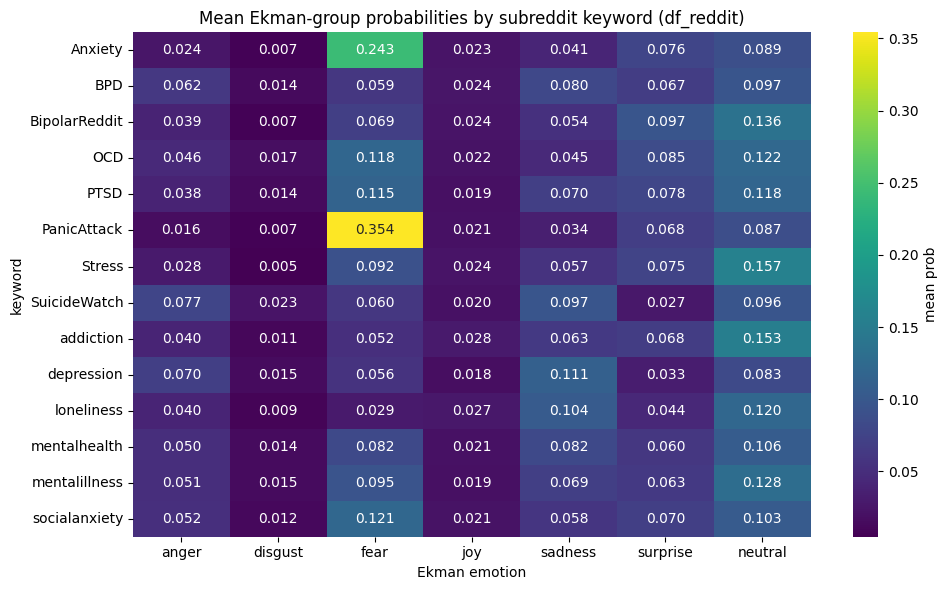

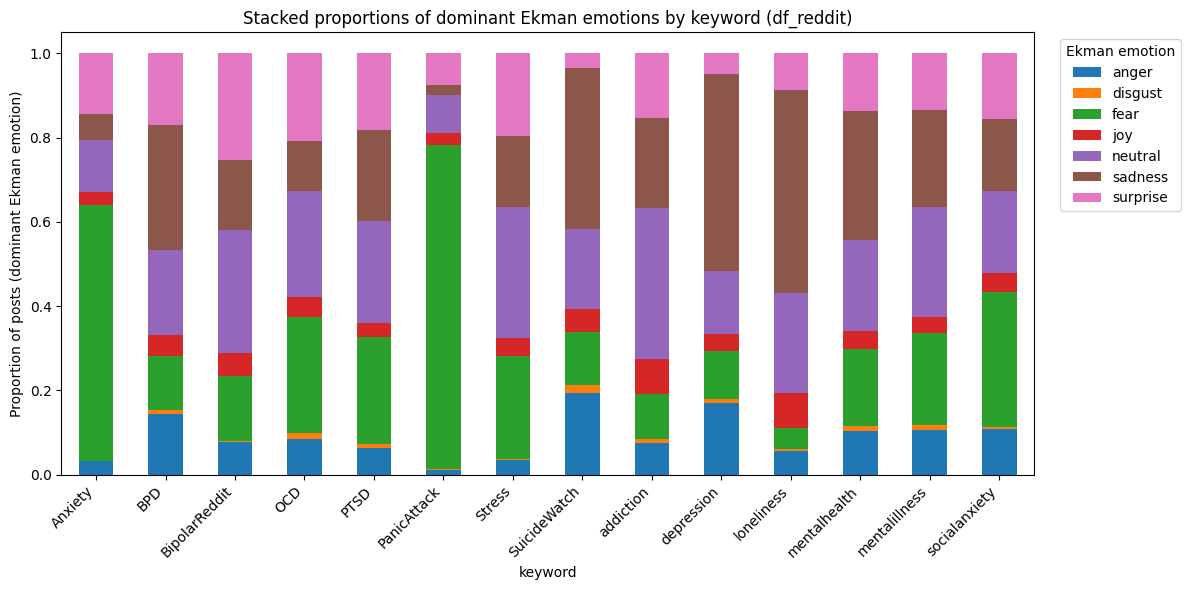

In [7]:
# Visualizations on df_samp: heatmap (mean Ekman probs per keyword) + stacked bar (dominant Ekman proportions)
# Reuses existing variables: ekman_prob_cols, ekman_groups, keywords, dominant_counts (will recompute from df_samp if missing)

# 1) Heatmap of mean Ekman-group probabilities per keyword (from df_samp)
mean_probs = df_reddit.groupby('keyword')[ekman_prob_cols].mean()
mean_probs.columns = ekman_groups  # friendlier labels

# robustly obtain keyword ordering: prefer existing `keywords` if defined, else derive from mean_probs
try:
    kws = keywords
except NameError:
    kws = mean_probs.index.tolist()

plt.figure(figsize=(10, 6))
sns.heatmap(mean_probs.reindex(kws), cmap='viridis', annot=True, fmt=".3f", cbar_kws={'label': 'mean prob'})
plt.title("Mean Ekman-group probabilities by subreddit keyword (df_reddit)")
plt.ylabel("keyword")
plt.xlabel("Ekman emotion")
plt.tight_layout()
plt.show()

# 2) Stacked bar chart of dominant Ekman emotion proportions per keyword
try:
    counts = dominant_counts.copy()
except NameError:
    counts = df_reddit.groupby(['keyword','goe_ekman_dominant']).size().unstack(fill_value=0)

# normalize rows -> proportions and ensure same keyword ordering
prop = counts.div(counts.sum(axis=1), axis=0).reindex(kws).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("tab10", n_colors=len(ekman_groups))
prop.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_ylabel("Proportion of posts (dominant Ekman emotion)")
ax.set_xlabel("keyword")
ax.set_title("Stacked proportions of dominant Ekman emotions by keyword (df_reddit)")
ax.legend(title="Ekman emotion", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


NameError: name 'df_vis' is not defined

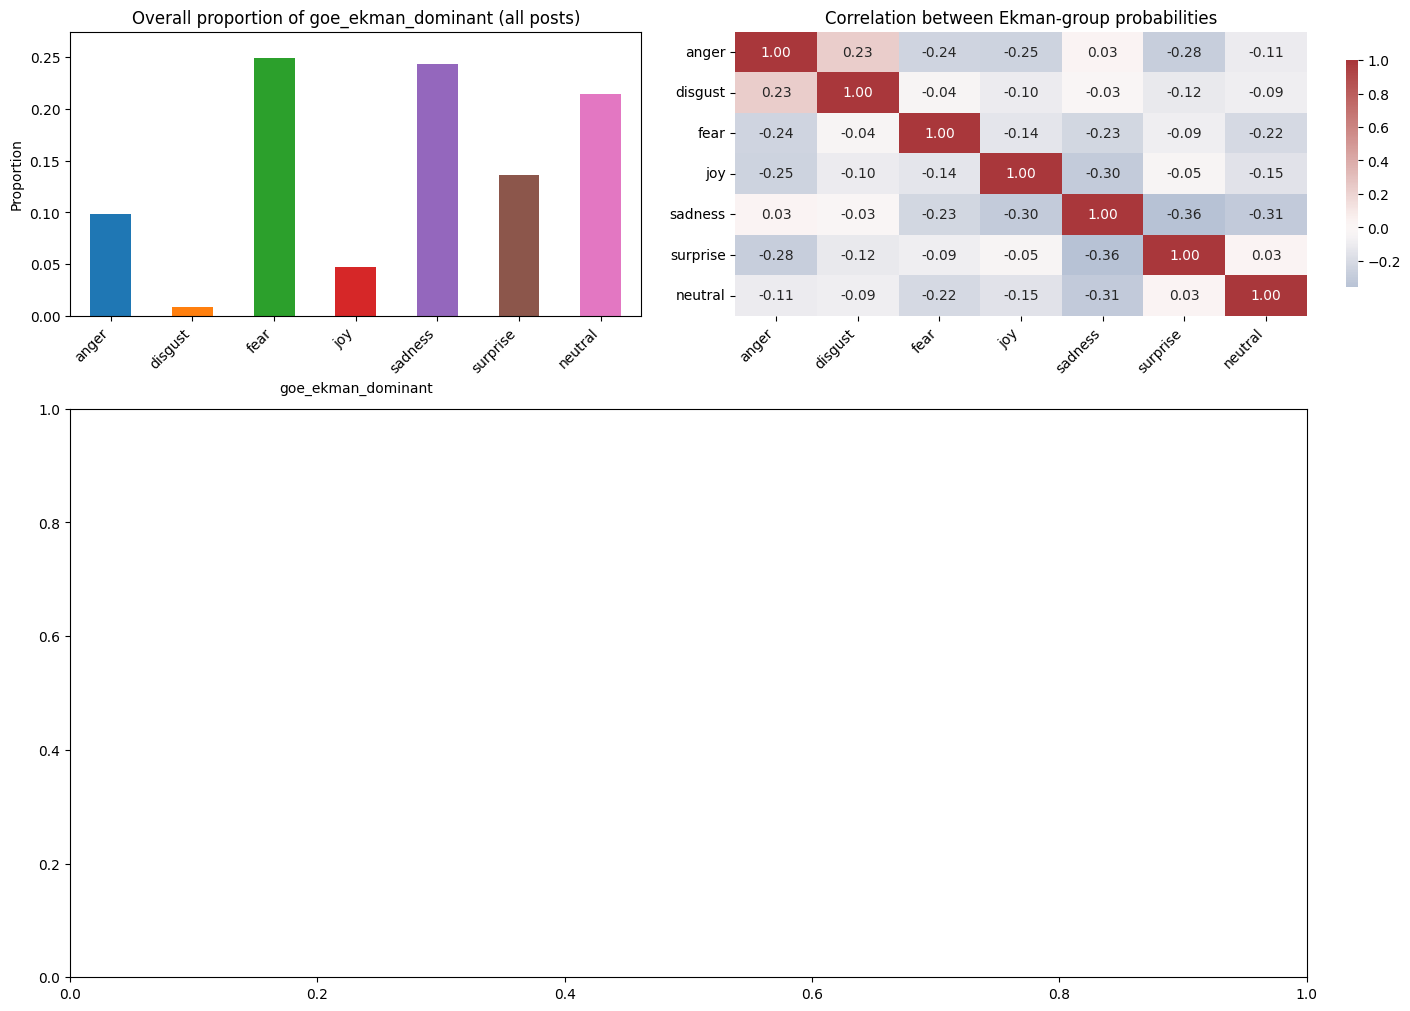

In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Visualization cell: overall dominant distribution, ekman prob correlation heatmap, and 2D TSNE scatter

# 1) Overall distribution of Ekman dominant labels
fig = plt.figure(constrained_layout=True, figsize=(14, 10))
gs = fig.add_gridspec(3, 2)

ax_bar = fig.add_subplot(gs[0, 0])
dominant_counts_total = df_reddit['goe_ekman_dominant'].value_counts(normalize=True).reindex(ekman_groups).fillna(0)
dominant_counts_total.plot(kind='bar', ax=ax_bar, color=sns.color_palette("tab10", n_colors=len(ekman_groups)))
ax_bar.set_ylabel("Proportion")
ax_bar.set_title("Overall proportion of goe_ekman_dominant (all posts)")
ax_bar.set_ylim(0, dominant_counts_total.max() * 1.1)
ax_bar.set_xticklabels(ax_bar.get_xticklabels(), rotation=45, ha='right')

# 2) Correlation heatmap of Ekman-group probabilities (shows relationships between groups)
ax_heat = fig.add_subplot(gs[0, 1])
corr = df_reddit[ekman_prob_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax_heat, cbar_kws={'shrink': .8})
ax_heat.set_title("Correlation between Ekman-group probabilities")
ax_heat.set_xticklabels(ekman_groups, rotation=45, ha='right')
ax_heat.set_yticklabels(ekman_groups, rotation=0)



ax_tsne = fig.add_subplot(gs[1:, :])
# palette for ekman_groups
palette = dict(zip(ekman_groups, sns.color_palette("tab10", n_colors=len(ekman_groups))))
sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='dominant', palette=palette, s=20, alpha=0.8, ax=ax_tsne, linewidth=0)
ax_tsne.set_title(f"t-SNE of Ekman-group probabilities (sample n={sample_n}) colored by goe_ekman_dominant")
ax_tsne.legend(title='Ekman dominant', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

In [ ]:
df_reddit['goe_ekman_dominant'].value_counts()

goe_ekman_dominant
fear        12090
sadness     11809
neutral     10402
surprise     6603
anger        4779
joy          2287
disgust       434
Name: count, dtype: int64

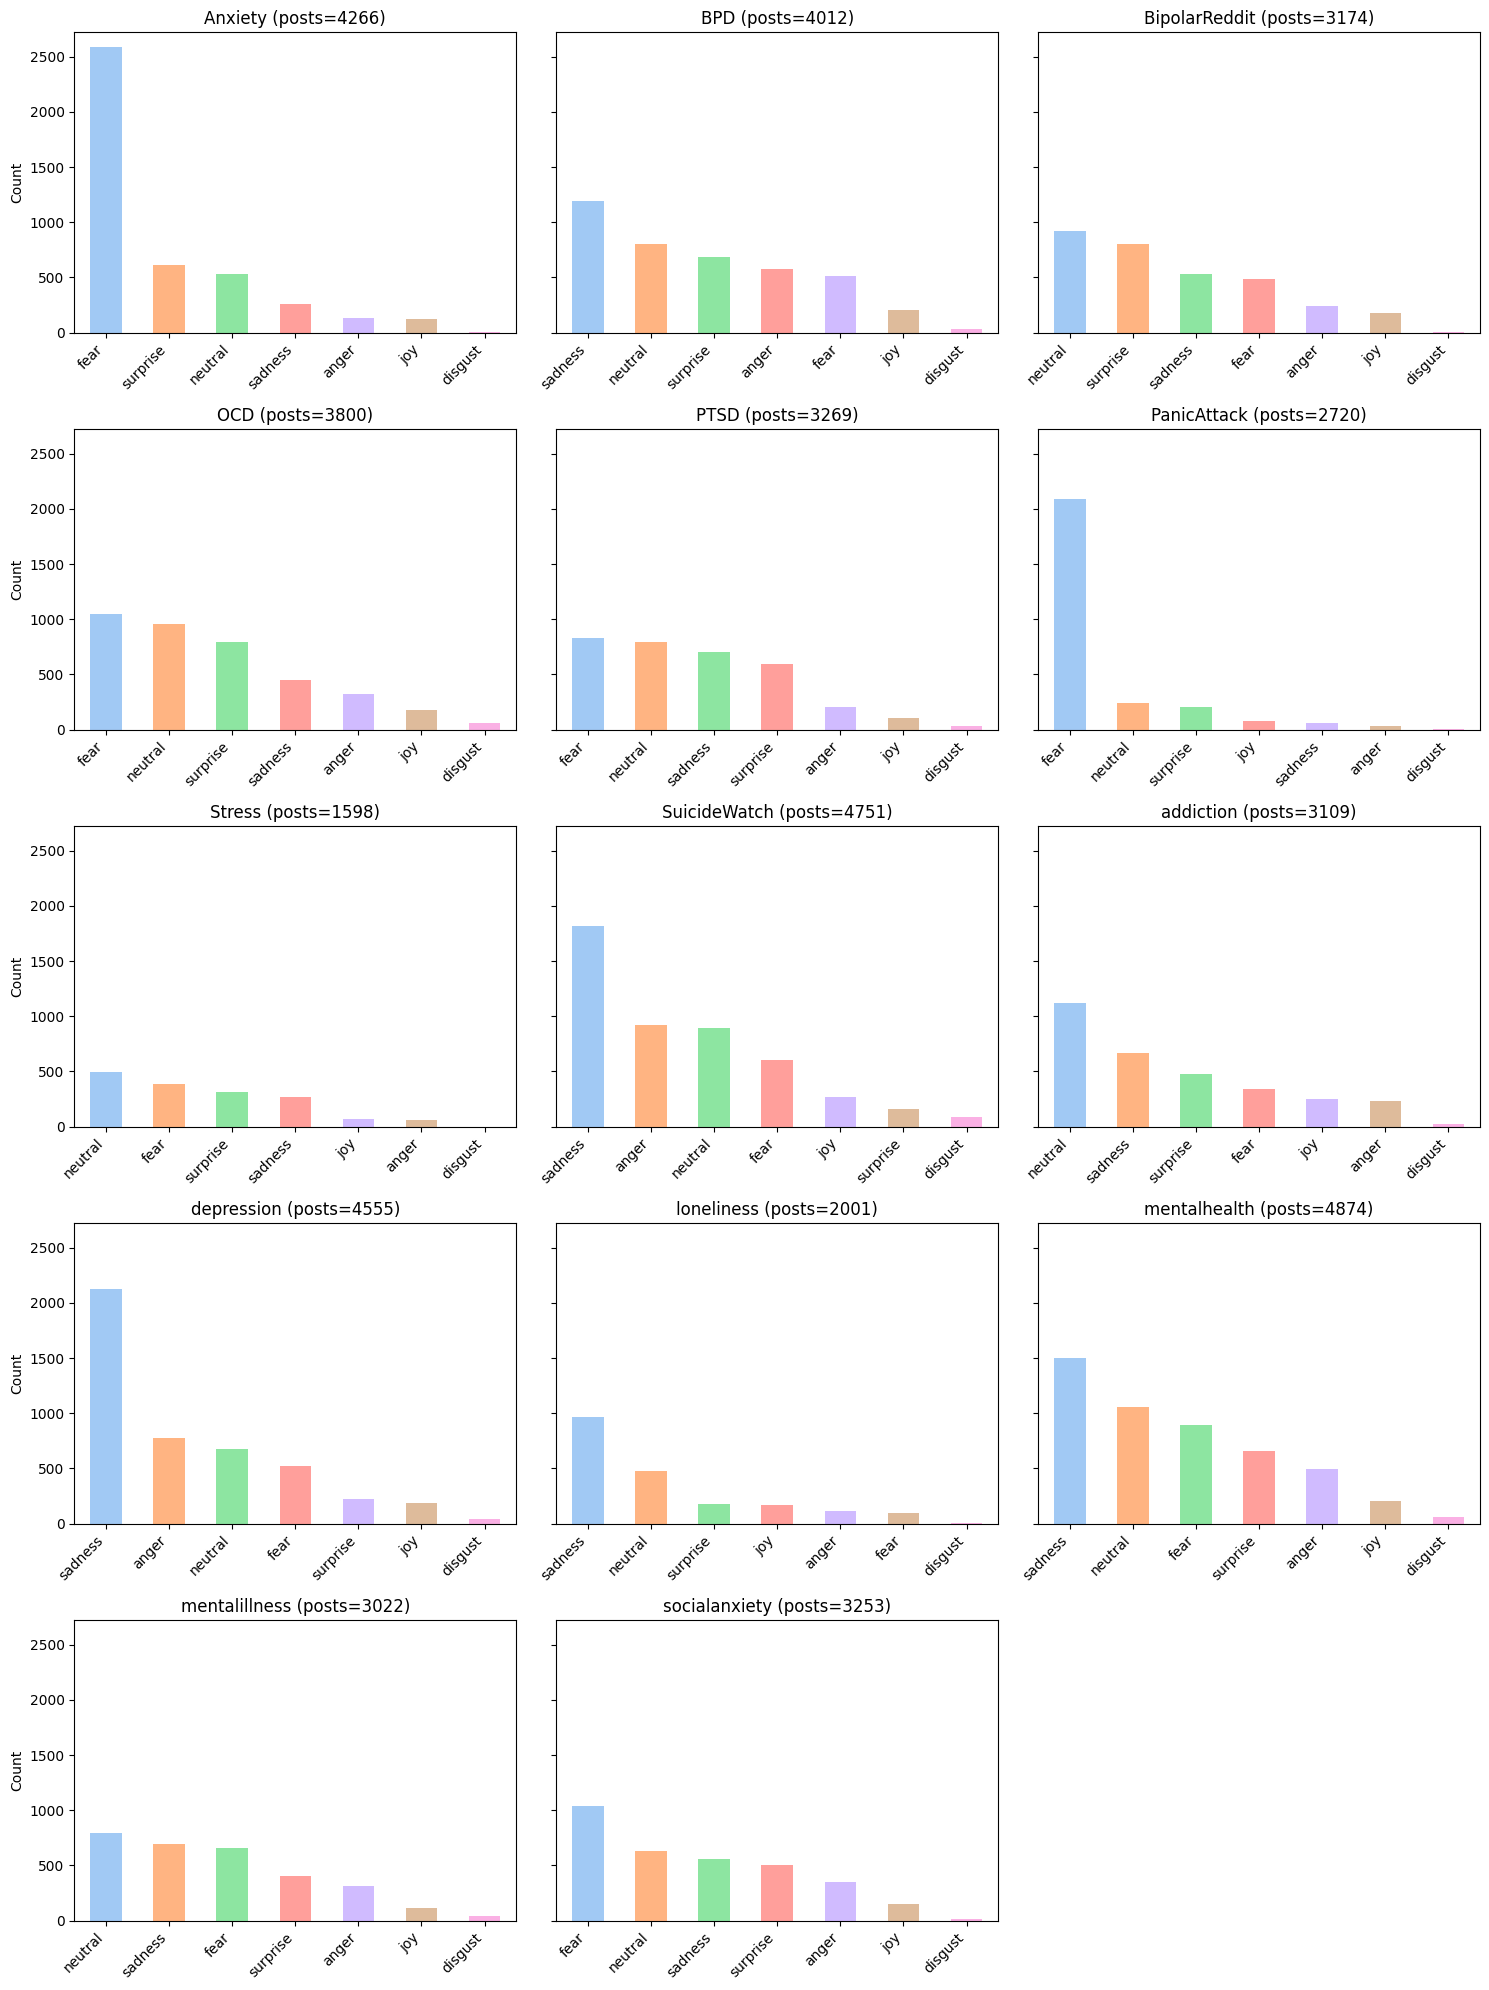

In [ ]:
import math

# Plot dominant GoEmotions distribution per reddit keyword

emotion_col = 'goe_ekman_dominant'
if emotion_col not in df_reddit.columns:
    raise RuntimeError(f"Column '{emotion_col}' not found in df_reddit. Run the GoEmotions → Ekman mapping cells first.")

# group and pivot
dominant_counts = df_reddit.groupby(['keyword', emotion_col]).size().unstack(fill_value=0)

keywords = dominant_counts.index.tolist()
n = len(keywords)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4), sharey=True)
axes = axes.flatten()

for i, kw in enumerate(keywords):
    ax = axes[i]
    series = dominant_counts.loc[kw].sort_values(ascending=False)
    series.plot(kind='bar', ax=ax, color=sns.color_palette("pastel", n_colors=len(series)))
    ax.set_title(f'{kw} (posts={int(series.sum())})')
    ax.set_xlabel('')
    if i % ncols == 0:
        ax.set_ylabel('Count')
    else:
        ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# hide any extra axes
for j in range(len(keywords), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#convert to csv
df_reddit.to_csv('reddit_goemotions_ekman.csv', index=False)